<a href="https://colab.research.google.com/github/PoisonMunna/Student_Performance_Analytics/blob/main/Student_Performance_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This is a simple student perfomance Analytics data ready process.
## First we extract all the detail of the data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the data
df = pd.read_csv('/StudentsPerformance.csv')

## Initial Data Exploration--------------------------------------------------------------------------------------------------------------------------

# 1. Look at the data
print("--------------------------------------------------------------------------------------------------------------------------------------------")
print(df.head(10))
print("--------------------------------------------------------------------------------------------------------------------------------------------")
print(df.tail(10))
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 2. Understand the structure
print(df.info())
print("--------------------------------------------------------------------------------------------------------------------------------------------")
print(df.shape)  # (rows, columns)
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 3. Statistical summary
print(df.describe())
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 4. Check for missing values
print(df.isnull().sum())
print("--------------------------------------------------------------------------------------------------------------------------------------------")

# 5. Check unique values in categorical columns
categorical_cols = ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
print("--------------------------------------------------------------------------------------------------------------------------------------------")


--------------------------------------------------------------------------------------------------------------------------------------------
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test_preparation_course  math_score  reading_score  writing_score  
0                 

## Data Cleaning and Preprocessing
### If there are missing values (unlikely in this dataset, but good practice)
### For numerical: df['column'].fillna(df['column'].mean(), inplace=True)
#### For categorical: df['column'].fillna('Unknown', inplace=True)

In [ ]:
# Rename columns for easier access (optional)
df.rename(columns={
    'math_score': 'math',
    'reading_score': 'reading',
    'writing_score': 'writing'
}, inplace=True)

# Create a total/average score column
df['total_score'] = df['math'] + df['reading'] + df['writing']
df['average_score'] = df['total_score'] / 3

print(df.head(10))
print("---------------------------------------------------------------------------------------------------------------------------------------------")


   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test_preparation_course  math  reading  writing  total_score  average_score  
0                    none    72       72       74          218      72.666667  
1               completed    69       90       88          247      8

## Visualization


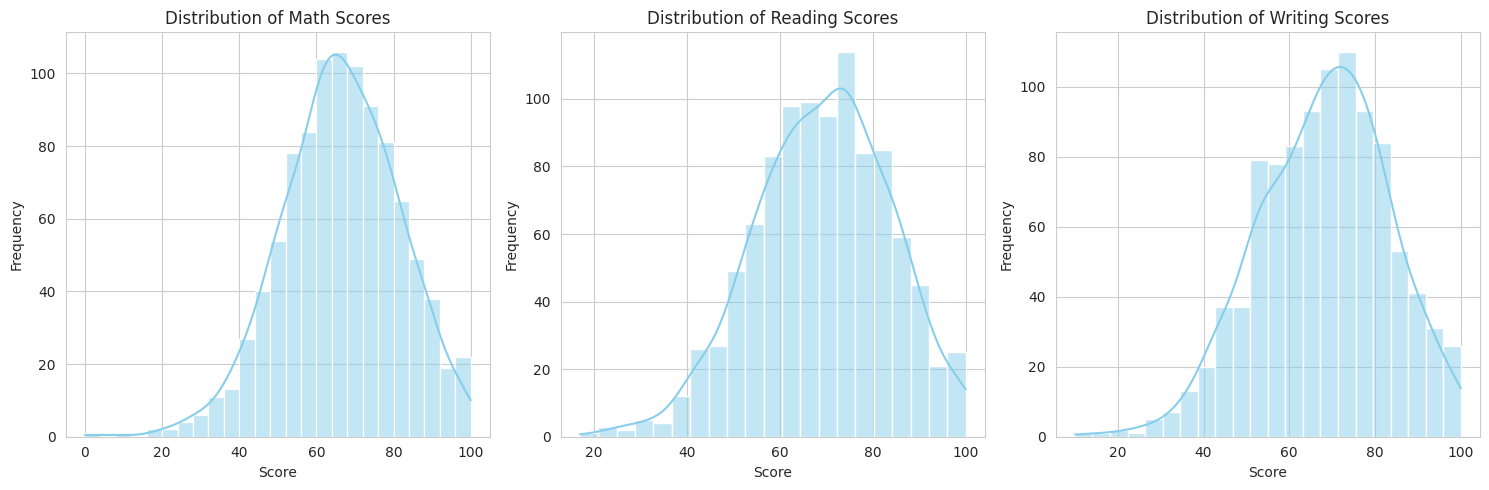

In [ ]:
## A. Distribution of Scores
## 1. Histograms of all three subjects

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
subjects = ['math', 'reading', 'writing']

for i, subject in enumerate(subjects):
    sns.histplot(df[subject], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {subject.capitalize()} Scores')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

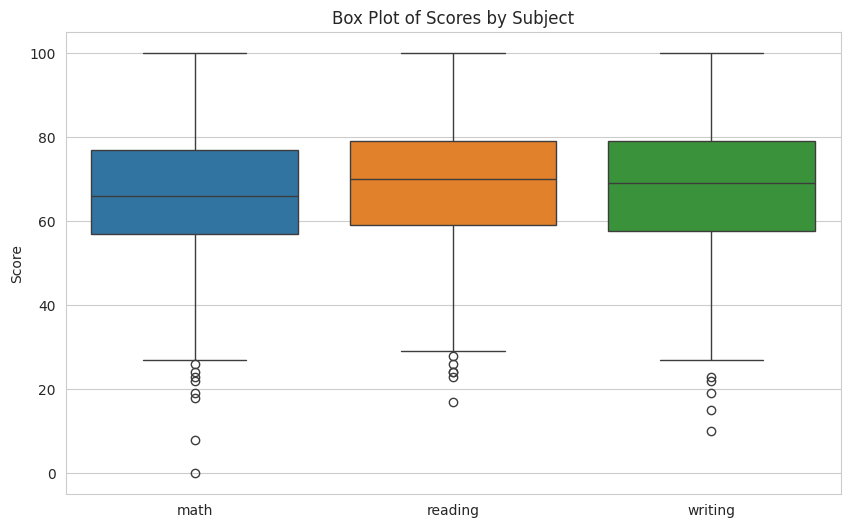

In [ ]:
# 2. Box plots to check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['math', 'reading', 'writing']])
plt.title('Box Plot of Scores by Subject')
plt.ylabel('Score')
plt.show()

<Figure size 1000x600 with 0 Axes>

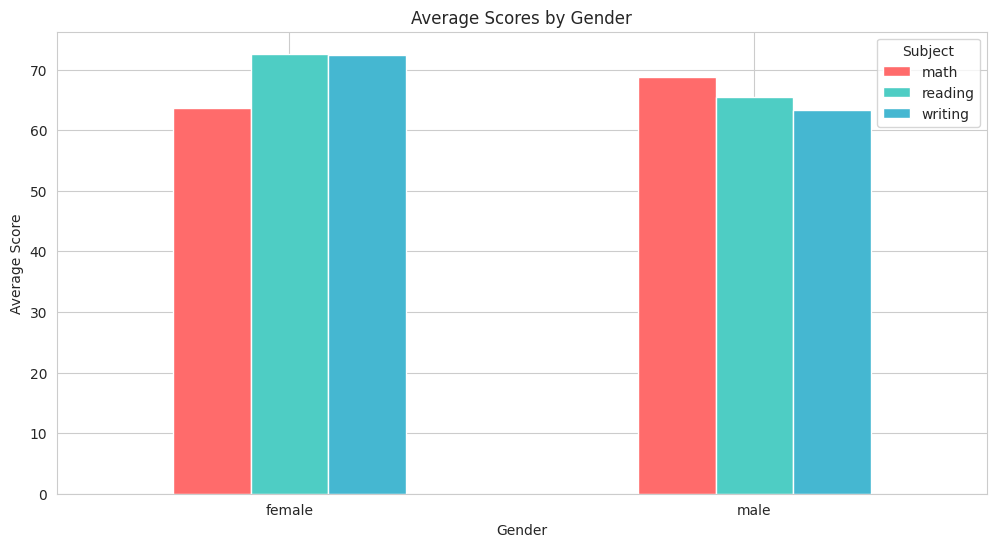

In [ ]:
# B. Gender-based Analysis
# 1. Compare scores by gender
plt.figure(figsize=(10, 6))
gender_scores = df.groupby('gender')[['math', 'reading', 'writing']].mean()
gender_scores.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Average Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.show()

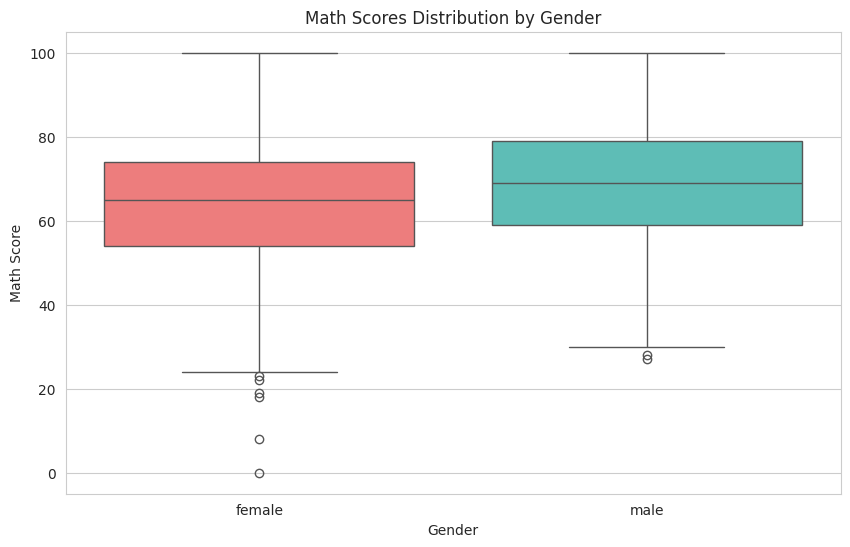

In [ ]:
# 2. Box plot for math scores by gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='math', data=df, palette=['#FF6B6B', '#4ECDC4'], hue='gender', legend=False)
plt.xlabel('Gender')
plt.ylabel('Math Score')
plt.title('Math Scores Distribution by Gender')
plt.show()

<Figure size 1200x600 with 0 Axes>

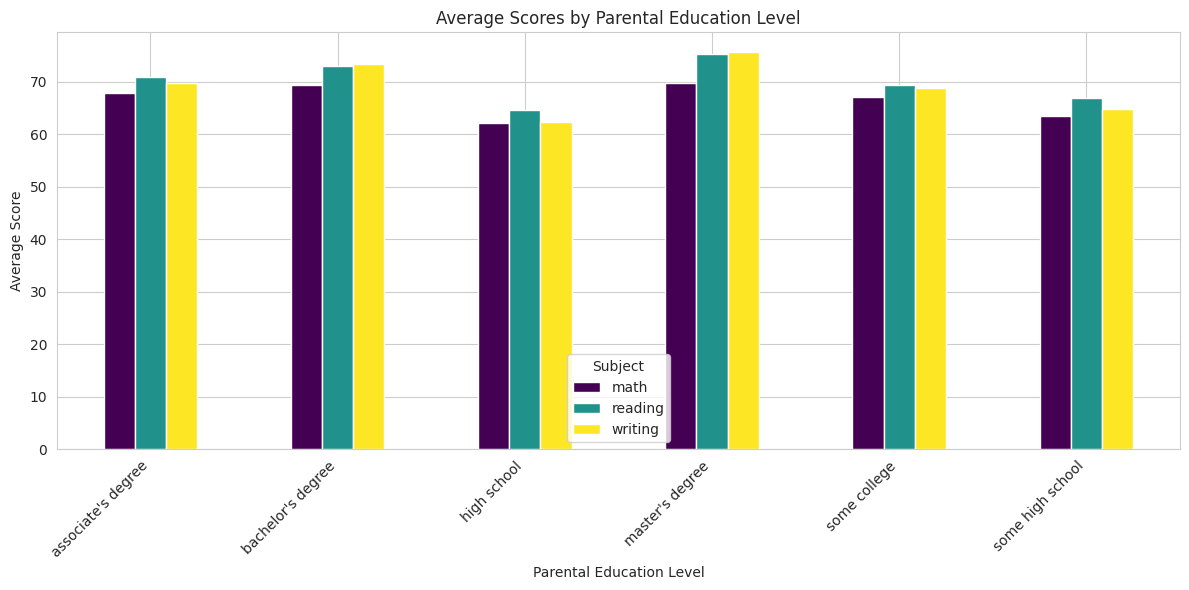

In [ ]:
# C. Parental Education Level Analysis
# 1. Impact of parental education on scores
plt.figure(figsize=(12, 6))
edu_scores = df.groupby('parental_level_of_education')[['math', 'reading', 'writing']].mean()
edu_scores.plot(kind='bar', colormap='viridis')
plt.title('Average Scores by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

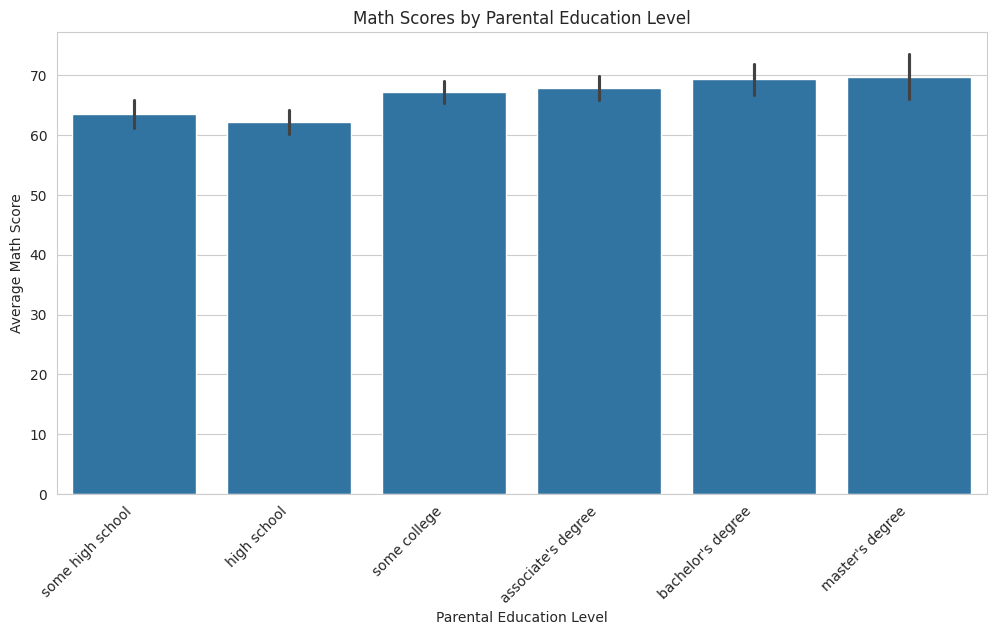

In [ ]:
# 2. Only math score by parental education
plt.figure(figsize=(12, 6))
sns.barplot(x='parental_level_of_education', y='math', data=df,
            order=['some high school', 'high school', 'some college',
                   'associate\'s degree', 'bachelor\'s degree', 'master\'s degree'])
plt.title('Math Scores by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Average Math Score')
plt.xticks(rotation=45, ha='right')
plt.show()

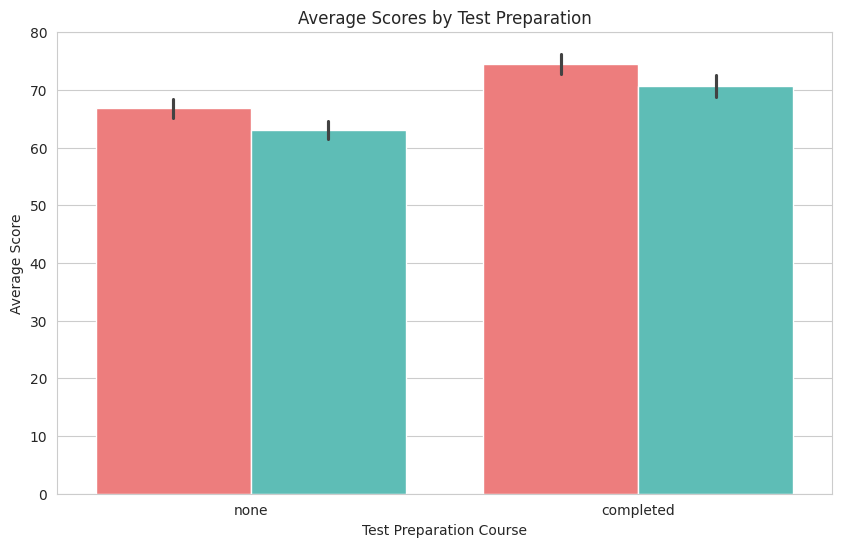

In [ ]:
# D. Test Preparation Course Analysis
# 1. Compare scores with and without test prep
plt.figure(figsize=(10, 6))
sns.barplot(x='test_preparation_course', y='average_score', data=df,
            palette=['#FF6B6B', '#4ECDC4'], hue='gender', legend=False)
plt.title('Average Scores by Test Preparation')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.show()

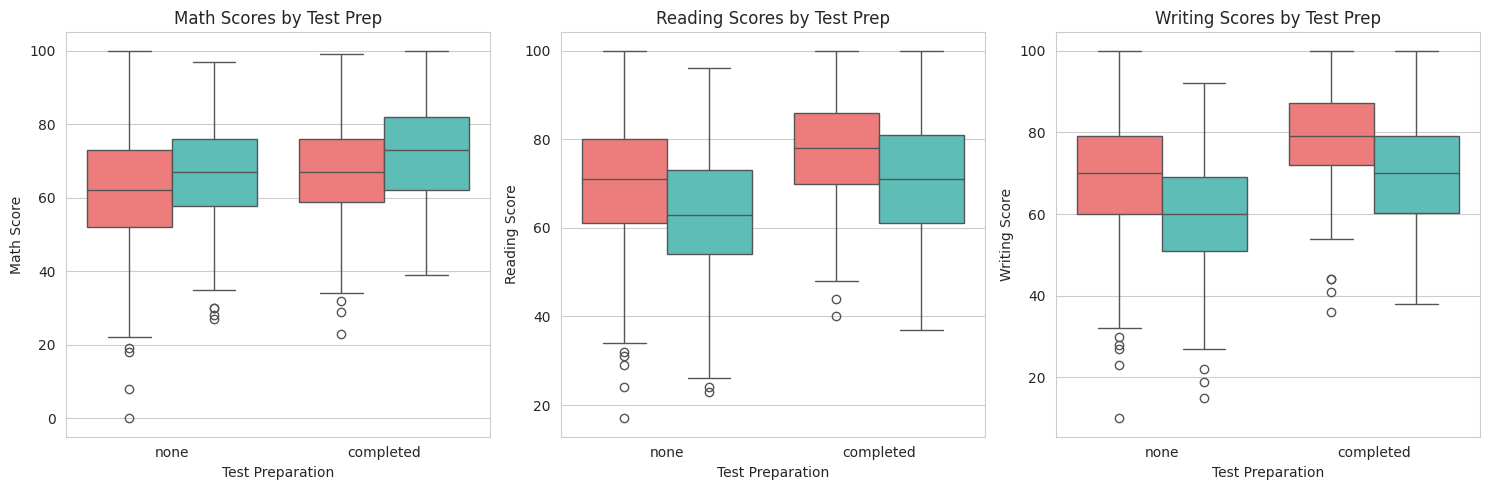

In [ ]:
# 2. Facet grid showing all subjects
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, subject in enumerate(['math', 'reading', 'writing']):
    sns.boxplot(x='test_preparation_course', y=subject, data=df, ax=axes[i],
                palette=['#FF6B6B', '#4ECDC4'], hue='gender', legend=False)
    axes[i].set_title(f'{subject.capitalize()} Scores by Test Prep')
    axes[i].set_xlabel('Test Preparation')
    axes[i].set_ylabel(f'{subject.capitalize()} Score')
plt.tight_layout()
plt.show()


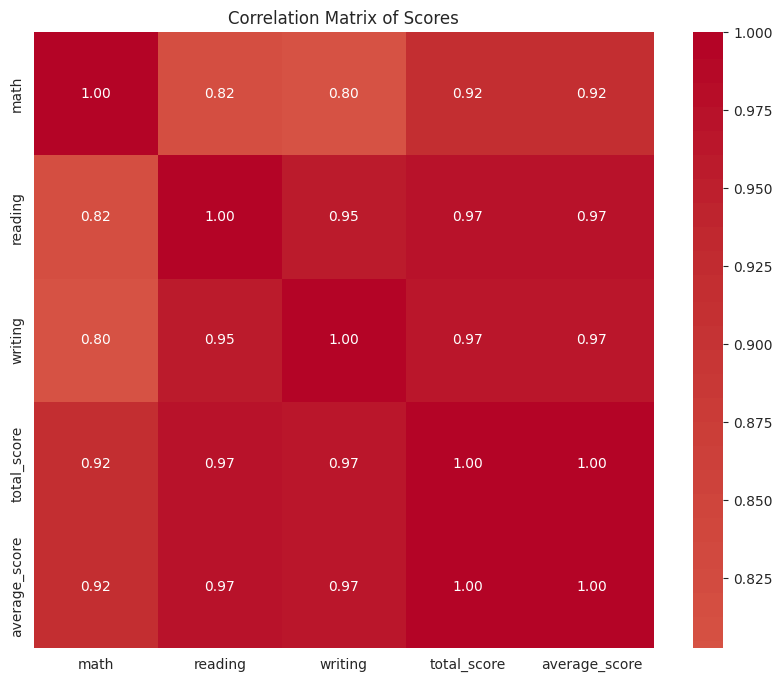

In [ ]:
# E. Correlation Analysis
# 1. Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['math', 'reading', 'writing', 'total_score', 'average_score']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Scores')
plt.show()

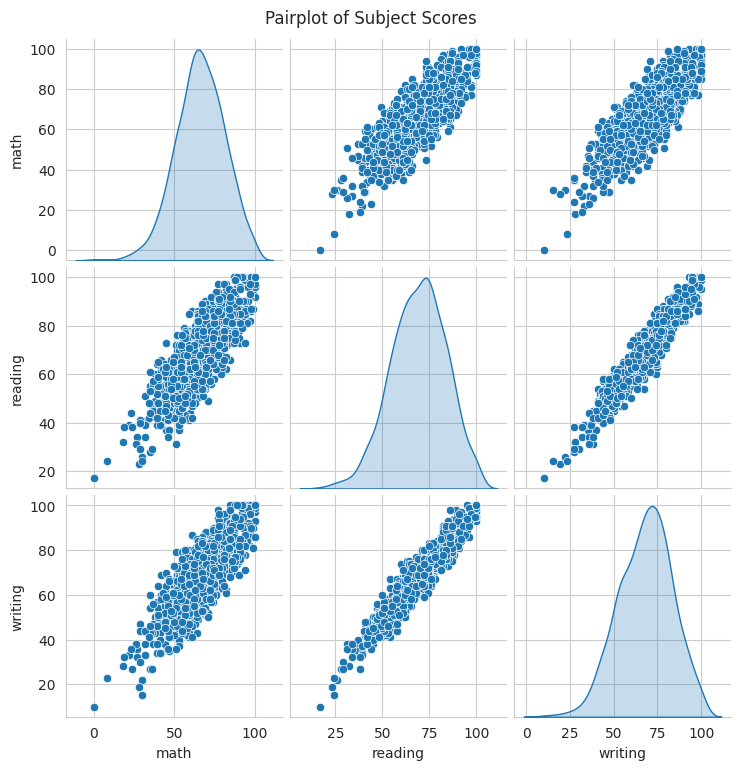

In [ ]:
# 2. Pairplot (only if you have less data, but with 1000 rows it's okay)
sns.pairplot(df[['math', 'reading', 'writing']], diag_kind='kde')
plt.suptitle('Pairplot of Subject Scores', y=1.02)
plt.show()

## SUMMARY AND CONCLUSIONS


In [ ]:
## SUMMARY AND CONCLUSIONS
# Create a summary report
print("\n\n")
print("----------------------------------------------------------------------------------------------------------------------------------------------------")
print("----------------------------------------------------------------------------------------------------------------------------------------------------")
print("="*50)
print("STUDENT PERFORMANCE ANALYSIS - KEY FINDINGS")
print("="*50)

print(f"\n1. Average Scores:")
print(f"   Math: {df['math'].mean():.2f}")
print(f"   Reading: {df['reading'].mean():.2f}")
print(f"   Writing: {df['writing'].mean():.2f}")

print(f"\n2. Gender Differences:")
for subject in ['math', 'reading', 'writing']:
    male_avg = df[df['gender'] == 'male'][subject].mean()
    female_avg = df[df['gender'] == 'female'][subject].mean()
    print(f"   {subject.capitalize()}: Male={male_avg:.2f}, Female={female_avg:.2f}")

print(f"\n3. Test Preparation Effect:")
prep_yes = df[df['test_preparation_course'] == 'completed']['average_score'].mean()
prep_no = df[df['test_preparation_course'] == 'none']['average_score'].mean()
print(f"   With Prep: {prep_yes:.2f}")
print(f"   Without Prep: {prep_no:.2f}")
print(f"   Difference: {prep_yes - prep_no:.2f} points")

print(f"\n4. Correlation Between Subjects:")
print(f"   Math vs Reading: {df['math'].corr(df['reading']):.3f}")
print(f"   Math vs Writing: {df['math'].corr(df['writing']):.3f}")
print(f"   Reading vs Writing: {df['reading'].corr(df['writing']):.3f}")
print("----------------------------------------------------------------------------------------------------------------------------------------------------")
print("----------------------------------------------------------------------------------------------------------------------------------------------------")




----------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------
STUDENT PERFORMANCE ANALYSIS - KEY FINDINGS

1. Average Scores:
   Math: 66.09
   Reading: 69.17
   Writing: 68.05

2. Gender Differences:
   Math: Male=68.73, Female=63.63
   Reading: Male=65.47, Female=72.61
   Writing: Male=63.31, Female=72.47

3. Test Preparation Effect:
   With Prep: 72.67
   Without Prep: 65.04
   Difference: 7.63 points

4. Correlation Between Subjects:
   Math vs Reading: 0.818
   Math vs Writing: 0.803
   Reading vs Writing: 0.955
----------------------------------------------------------------------------------------------------------------------------------------------------
-----------------------------------------------------------------------------------------